# **Imports and Loading Dataset**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.model_selection import KFold, cross_val_score, RandomizedSearchCV, learning_curve, train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from scipy.stats import loguniform

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

In [3]:
df = pd.read_csv("train_data.csv")
df_test = pd.read_csv("test_data.csv")

## **Some Initial Insights**

In [4]:
df.head()

,id,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   881 non-null    int64  
 1   Company              881 non-null    object 
 2   Product              881 non-null    object 
 3   TypeName             881 non-null    object 
 4   Inches               881 non-null    float64
 5   ScreenResolution     881 non-null    object 
 6   CPU_Company          881 non-null    object 
 7   CPU_Type             881 non-null    object 
 8   CPU_Frequency (GHz)  881 non-null    float64
 9   RAM (GB)             881 non-null    int64  
 10  Memory               881 non-null    object 
 11  GPU_Company          881 non-null    object 
 12  GPU_Type             881 non-null    object 
 13  OpSys                881 non-null    object 
 14  Weight (kg)          881 non-null    float64
 15  Price (Euro)         881 non-null    flo

In [6]:
df.shape

(881, 16)

In [7]:
df.describe()

,id,Inches,CPU_Frequency (GHz),RAM (GB),Weight (kg),Price (Euro)
count,881.00000,881.000000,881.000000,881.000000,881.000000,881.000000
mean,441.00000,15.085017,2.281839,8.522134,2.049714,1110.183235
std,254.46709,1.396360,0.527334,4.921176,0.657077,711.526332
min,1.00000,10.100000,0.900000,2.000000,0.690000,191.900000
25%,221.00000,14.000000,1.800000,4.000000,1.580000,589.000000
50%,441.00000,15.600000,2.500000,8.000000,2.040000,945.000000
75%,661.00000,15.600000,2.700000,8.000000,2.300000,1426.660000
max,881.00000,18.400000,3.600000,32.000000,4.700000,6099.000000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

id                     0
Company                0
Product                0
TypeName               0
Inches                 0
ScreenResolution       0
CPU_Company            0
CPU_Type               0
CPU_Frequency (GHz)    0
RAM (GB)               0
Memory                 0
GPU_Company            0
GPU_Type               0
OpSys                  0
Weight (kg)            0
Price (Euro)           0
dtype: int64

In [10]:
df.drop(columns=['id'], inplace=True)

In [11]:
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro)
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60


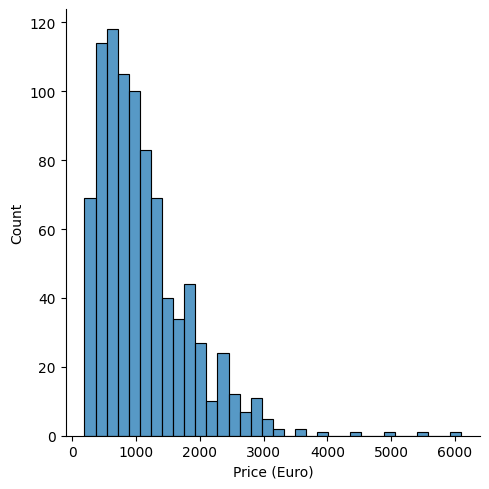

In [12]:
sns.displot(df['Price (Euro)'])

<Axes: xlabel='Company'>

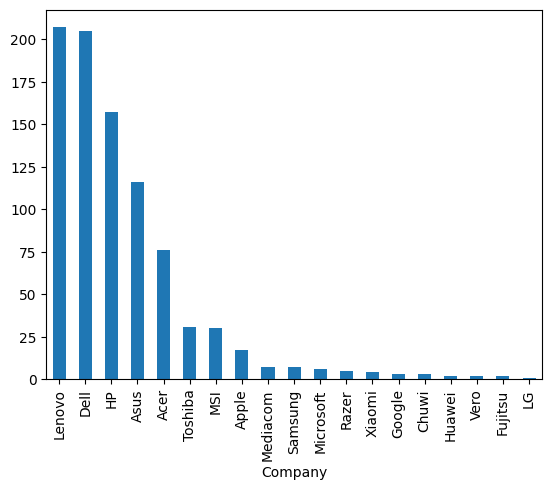

In [13]:
df['Company'].value_counts().plot(kind='bar')

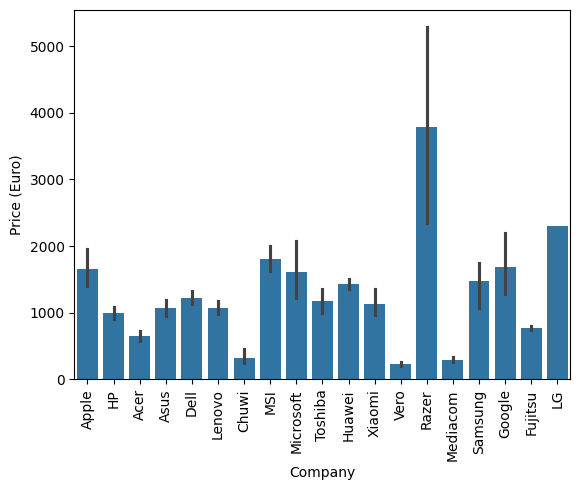

In [14]:
sns.barplot(x=df['Company'],y=df['Price (Euro)'])
plt.xticks(rotation='vertical')
plt.show()

<Axes: xlabel='TypeName'>

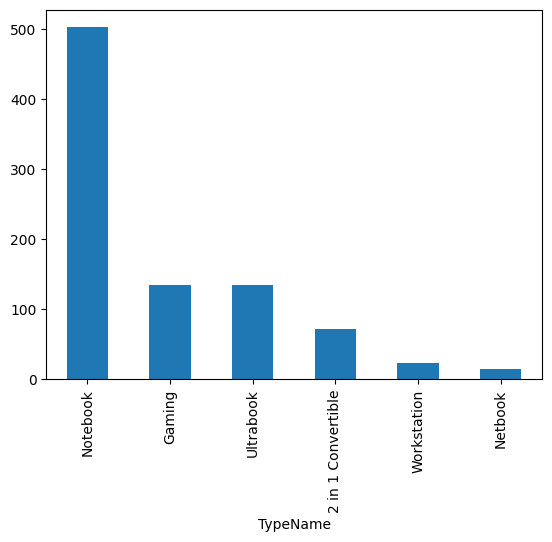

In [15]:
df['TypeName'].value_counts().plot(kind='bar')

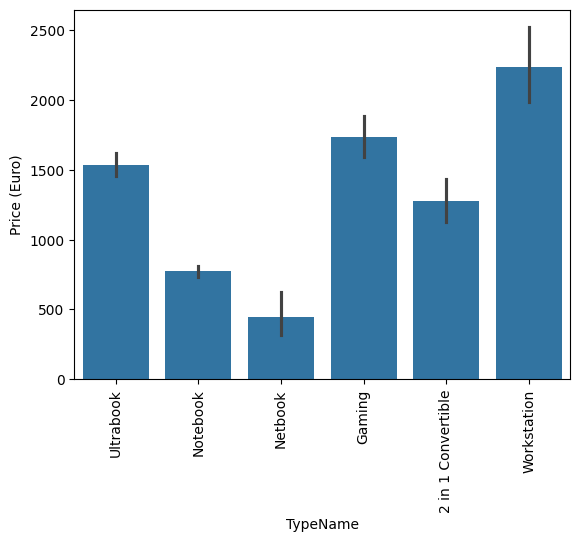

In [16]:
sns.barplot(x=df['TypeName'],y=df['Price (Euro)'])
plt.xticks(rotation='vertical')
plt.show()

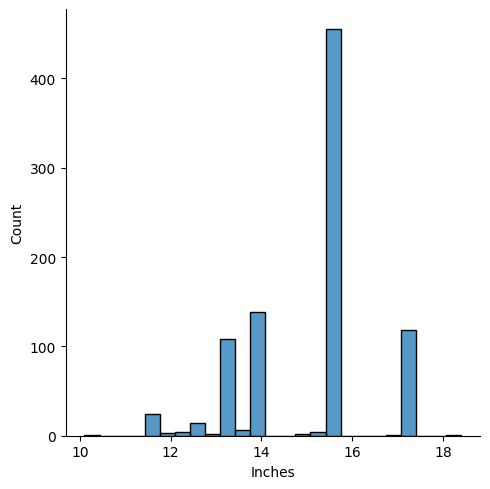

In [17]:
sns.displot(df['Inches'])

<Axes: xlabel='Inches', ylabel='Price (Euro)'>

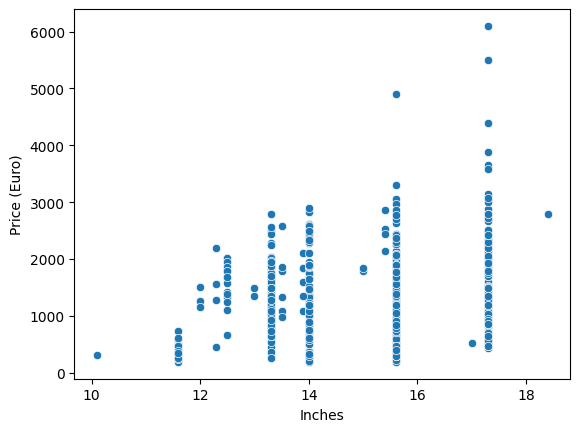

In [18]:
sns.scatterplot(x=df['Inches'],y=df['Price (Euro)'])

# **Feature Engineering**

In [19]:
df['Touchscreen'] = df['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)
df_test['Touchscreen'] = df_test['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)

In [20]:
df.head(20)

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),Touchscreen
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69,0
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94,0
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00,0
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45,0
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60,0
5,Acer,Aspire 3,Notebook,15.6,1366x768,AMD,A9-Series 9420,3.0,4,500GB HDD,AMD,Radeon R5,Windows 10,2.10,400.00,0
6,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.2,16,256GB Flash Storage,Intel,Iris Pro Graphics,Mac OS X,2.04,2139.97,0
7,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,256GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,1158.70,0
8,Asus,ZenBook UX430UN,Ultrabook,14.0,Full HD 1920x1080,Intel,Core i7 8550U,1.8,16,512GB SSD,Nvidia,GeForce MX150,Windows 10,1.30,1495.00,0
9,Acer,Swift 3,Ultrabook,14.0,IPS Panel Full HD 1920x1080,Intel,Core i5 8250U,1.6,8,256GB SSD,Intel,UHD Graphics 620,Windows 10,1.60,770.00,0


<Axes: xlabel='Touchscreen'>

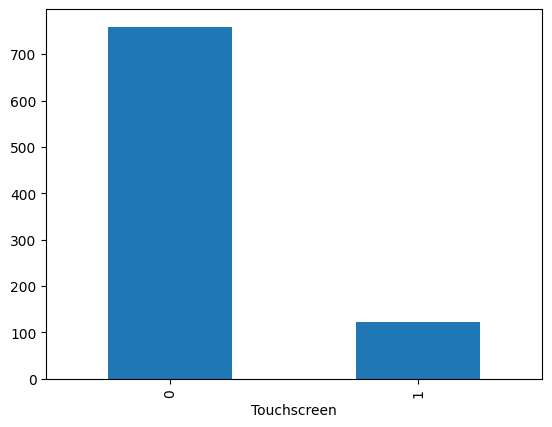

In [21]:
df['Touchscreen'].value_counts().plot(kind='bar')

<Axes: xlabel='Touchscreen', ylabel='Price (Euro)'>

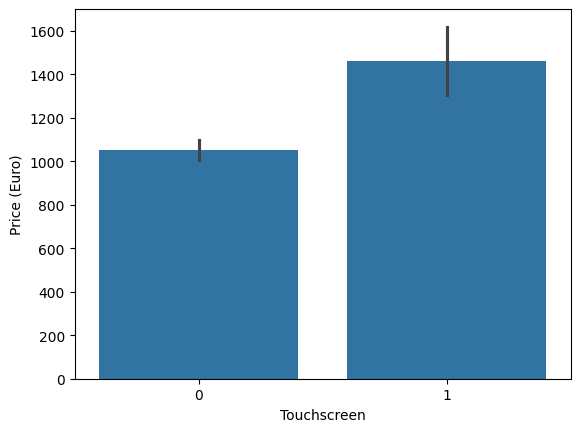

In [22]:
sns.barplot(x=df['Touchscreen'],y=df['Price (Euro)'])

In [23]:
df['Ips'] = df['ScreenResolution'].apply(lambda x:1 if 'IPS' in x else 0)
df_test['Ips'] = df_test['ScreenResolution'].apply(lambda x:1 if 'IPS' in x else 0)

In [24]:
df.head(10)

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),Touchscreen,Ips
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69,0,1
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94,0,0
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00,0,0
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45,0,1
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60,0,1
5,Acer,Aspire 3,Notebook,15.6,1366x768,AMD,A9-Series 9420,3.0,4,500GB HDD,AMD,Radeon R5,Windows 10,2.10,400.00,0,0
6,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel,Core i7,2.2,16,256GB Flash Storage,Intel,Iris Pro Graphics,Mac OS X,2.04,2139.97,0,1
7,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel,Core i5,1.8,8,256GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,1158.70,0,0
8,Asus,ZenBook UX430UN,Ultrabook,14.0,Full HD 1920x1080,Intel,Core i7 8550U,1.8,16,512GB SSD,Nvidia,GeForce MX150,Windows 10,1.30,1495.00,0,0
9,Acer,Swift 3,Ultrabook,14.0,IPS Panel Full HD 1920x1080,Intel,Core i5 8250U,1.6,8,256GB SSD,Intel,UHD Graphics 620,Windows 10,1.60,770.00,0,1


<Axes: xlabel='Ips'>

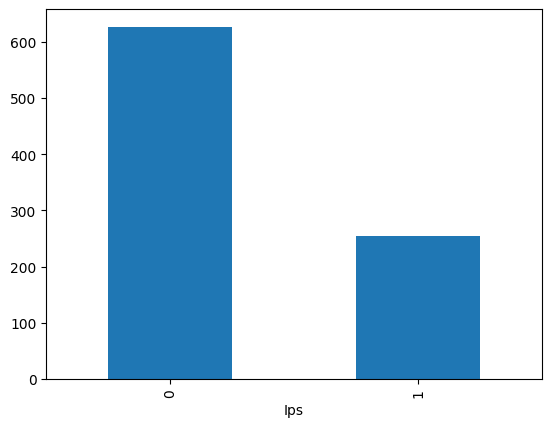

In [25]:
df['Ips'].value_counts().plot(kind='bar')

<Axes: xlabel='Ips', ylabel='Price (Euro)'>

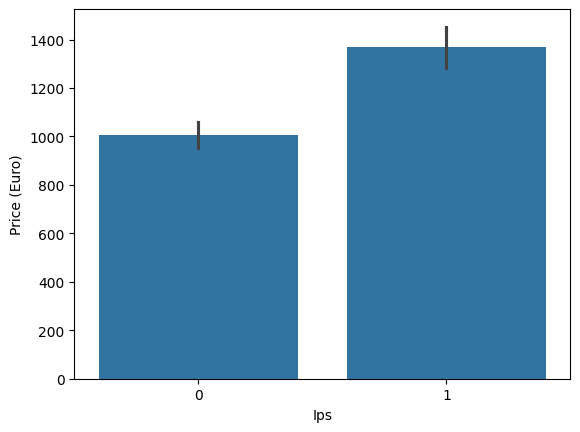

In [26]:
sns.barplot(x=df['Ips'],y=df['Price (Euro)'])

In [27]:
df[['X_res', 'Y_res']] = df['ScreenResolution'].str.extract(r'(\d+)x(\d+)').astype(int)
df_test[['X_res', 'Y_res']] = df_test['ScreenResolution'].str.extract(r'(\d+)x(\d+)').astype(int)

In [28]:
df.sample(10)

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),Touchscreen,Ips,X_res,Y_res
283,Lenovo,Ideapad 320-15IKBN,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,6,256GB SSD,Intel,HD Graphics 620,Windows 10,2.20,579.00,0,0,1920,1080
876,Asus,X541NA-GO121 (N4200/4GB/1TB/Linux),Notebook,15.6,1366x768,Intel,Pentium Quad Core N4200,1.1,4,1TB HDD,Intel,HD Graphics 505,Linux,2.00,398.99,0,0,1366,768
651,Acer,A715-71G-59DH (i5-7300HQ/8GB/1TB/GeForce,Gaming,15.6,Full HD 1920x1080,Intel,Core i5 7300HQ,2.5,8,1TB HDD,Nvidia,GeForce GTX 1050,Linux,2.40,709.00,0,0,1920,1080
119,Asus,VivoBook S15,Notebook,15.6,Full HD 1920x1080,Intel,Core i7 8550U,1.8,8,256GB SSD,Nvidia,GeForce 940MX,Windows 10,1.70,1118.00,0,0,1920,1080
306,HP,EliteBook x360,2 in 1 Convertible,13.3,Full HD / Touchscreen 1920x1080,Intel,Core i7 7600U,2.8,16,256GB SSD,Intel,HD Graphics 620,Windows 10,1.28,1975.00,1,0,1920,1080
176,Acer,Aspire A315-51,Notebook,15.6,1366x768,Intel,Core i3 6006U,2.0,4,128GB SSD,Intel,HD Graphics 520,Windows 10,2.10,449.00,0,0,1366,768
733,Acer,Extensa EX2540-58KR,Notebook,15.6,1366x768,Intel,Core i5 7200U,2.5,4,500GB HDD,Intel,HD Graphics 620,Windows 10,2.40,559.00,0,0,1366,768
106,Lenovo,Ideapad 310-15ISK,Notebook,15.6,Full HD 1920x1080,Intel,Core i3 6006U,2.0,4,1TB HDD,Intel,HD Graphics 520,Windows 10,1.85,414.90,0,0,1920,1080
500,Asus,VivoBook E201NA,Netbook,11.6,1366x768,Intel,Celeron Dual Core N3350,1.1,4,64GB Flash Storage,Intel,HD Graphics 500,Windows 10 S,1.20,340.00,0,0,1366,768
518,HP,Probook 450,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Nvidia,GeForce 930MX,Windows 10,2.04,889.00,0,0,1920,1080


In [29]:
df.sample(10)

,Company,Product,TypeName,Inches,ScreenResolution,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),Touchscreen,Ips,X_res,Y_res
277,Acer,Aspire A515-51G,Notebook,15.6,IPS Panel Full HD 1920x1080,Intel,Core i7 8550U,1.8,8,1TB HDD,Nvidia,GeForce MX130,Windows 10,2.20,745.0,0,1,1920,1080
734,Lenovo,ThinkPad 13,Notebook,13.3,IPS Panel Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,Windows 10,1.44,960.0,0,1,1920,1080
539,Lenovo,Thinkpad E470,Notebook,14.0,IPS Panel Full HD 1920x1080,Intel,Core i7 7500U,2.7,8,256GB SSD,Nvidia,GeForce 940MX,Windows 10,1.87,859.0,0,1,1920,1080
749,HP,Zbook 17,Workstation,17.3,IPS Panel Full HD 1920x1080,Intel,Xeon E3-1535M v5,2.9,16,256GB SSD,Nvidia,Quadro M2000M,Windows 7,3.00,4389.0,0,1,1920,1080
64,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,Windows 10,1.86,690.0,0,0,1920,1080
597,Lenovo,Thinkpad T470p,Notebook,14.0,IPS Panel Full HD 1920x1080,Intel,Core i5 7300HQ,2.5,8,256GB SSD,Intel,HD Graphics 630,Windows 10,1.70,1474.0,0,1,1920,1080
147,Asus,X541NA (N3350/4GB/1TB/FHD/W10),Notebook,15.6,Full HD 1920x1080,Intel,Celeron Dual Core N3350,1.1,4,1TB HDD,Intel,HD Graphics 500,Windows 10,2.00,344.0,0,0,1920,1080
478,Dell,Inspiron 3576,Notebook,15.6,Full HD 1920x1080,Intel,Core i5 8250U,1.6,8,1TB HDD,AMD,Radeon 520,Windows 10,2.20,675.0,0,0,1920,1080
655,Toshiba,Tecra A50-D-11M,Notebook,15.6,IPS Panel Full HD 1920x1080,Intel,Core i5 7200U,2.5,8,500GB HDD,Intel,HD Graphics 620,Windows 10,2.00,1064.0,0,1,1920,1080
218,Dell,Latitude 5490,Ultrabook,14.0,Full HD 1920x1080,Intel,Core i5 8250U,1.6,8,256GB SSD,Intel,UHD Graphics 620,Windows 10,1.60,1149.0,0,0,1920,1080


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              881 non-null    object 
 1   Product              881 non-null    object 
 2   TypeName             881 non-null    object 
 3   Inches               881 non-null    float64
 4   ScreenResolution     881 non-null    object 
 5   CPU_Company          881 non-null    object 
 6   CPU_Type             881 non-null    object 
 7   CPU_Frequency (GHz)  881 non-null    float64
 8   RAM (GB)             881 non-null    int64  
 9   Memory               881 non-null    object 
 10  GPU_Company          881 non-null    object 
 11  GPU_Type             881 non-null    object 
 12  OpSys                881 non-null    object 
 13  Weight (kg)          881 non-null    float64
 14  Price (Euro)         881 non-null    float64
 15  Touchscreen          881 non-null    int

In [31]:
df['ppi'] = (((df['X_res']**2) + (df['Y_res']**2))**0.5/df['Inches']).astype('float')
df_test['ppi'] = (((df_test['X_res']**2) + (df_test['Y_res']**2))**0.5/df_test['Inches']).astype('float')

df['ppi']=df['ppi'].fillna(df['ppi'].mean())
df_test['ppi']=df_test['ppi'].fillna(df['ppi'].mean())

<Axes: xlabel='ppi', ylabel='Price (Euro)'>

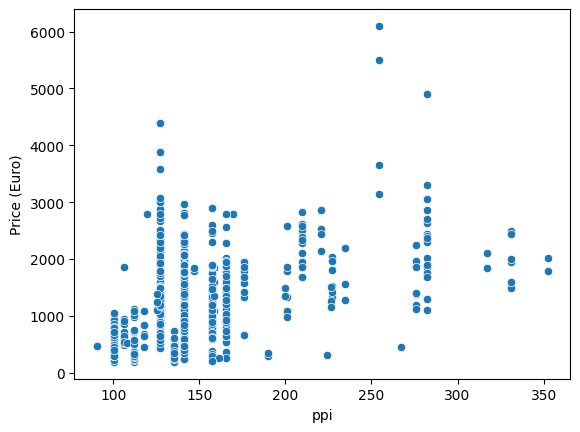

In [32]:
sns.scatterplot(x=df['ppi'],y=df['Price (Euro)'])

In [33]:
df['X_res'].sample(10)

355    1920
470    3840
421    2736
464    1920
723    3840
869    1920
52     1920
608    1920
807    1366
573    1920
Name: X_res, dtype: int64

In [34]:
df['X_res'].value_counts()

X_res
1920    597
1366    184
3840     33
2560     19
1600     16
3200      9
2256      6
2880      4
1440      4
2304      3
2400      3
2160      2
2736      1
Name: count, dtype: int64

In [35]:
df['Y_res'].value_counts()

Y_res
1080    595
768     184
2160     33
900      20
1440     18
1800     13
1600      9
1504      6
1200      2
1824      1
Name: count, dtype: int64

In [36]:
df.corr(numeric_only=True)['Price (Euro)']

Inches                 0.092347
CPU_Frequency (GHz)    0.451539
RAM (GB)               0.784077
Weight (kg)            0.241972
Price (Euro)           1.000000
Touchscreen            0.198150
Ips                    0.232332
X_res                  0.574924
Y_res                  0.572712
ppi                    0.490622
Name: Price (Euro), dtype: float64

In [37]:
df.drop(columns=['ScreenResolution','Inches','X_res','Y_res'],inplace=True)
df_test.drop(columns=['ScreenResolution','Inches','X_res','Y_res'],inplace=True)

In [38]:
df.head()

,Company,Product,TypeName,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,Weight (kg),Price (Euro),Touchscreen,Ips,ppi
0,Apple,MacBook Pro,Ultrabook,Intel,Core i5,2.3,8,128GB SSD,Intel,Iris Plus Graphics 640,macOS,1.37,1339.69,0,1,226.983005
1,Apple,Macbook Air,Ultrabook,Intel,Core i5,1.8,8,128GB Flash Storage,Intel,HD Graphics 6000,macOS,1.34,898.94,0,0,127.677940
2,HP,250 G6,Notebook,Intel,Core i5 7200U,2.5,8,256GB SSD,Intel,HD Graphics 620,No OS,1.86,575.00,0,0,141.211998
3,Apple,MacBook Pro,Ultrabook,Intel,Core i7,2.7,16,512GB SSD,AMD,Radeon Pro 455,macOS,1.83,2537.45,0,1,220.534624
4,Apple,MacBook Pro,Ultrabook,Intel,Core i5,3.1,8,256GB SSD,Intel,Iris Plus Graphics 650,macOS,1.37,1803.60,0,1,226.983005


In [39]:
df.drop(columns=['Product'],inplace=True)
df_test.drop(columns=['Product'],inplace=True)

In [40]:
df['CPU_Company'].value_counts().head(50)

CPU_Company
Intel    835
AMD       46
Name: count, dtype: int64

In [41]:
df['CPU_Type'].value_counts().head(50)

CPU_Type
Core i5 7200U              134
Core i7 7700HQ             117
Core i7 7500U               91
Core i5 8250U               71
Core i7 8550U               71
Core i3 6006U               63
Core i5 7300HQ              28
Celeron Dual Core N3350     27
Core i3 7100U               24
Core i5 6200U               22
Celeron Dual Core N3060     17
Core i7 6500U               13
Core i7 7600U               12
Core i5 7300U               12
A9-Series 9420              11
Core i5                     11
Pentium Quad Core N4200     11
Core i7 6700HQ               9
Core i3 7130U                8
Core i7 7820HK               7
Pentium Quad Core N3710      6
A6-Series 9220               6
Atom x5-Z8350                5
Core i7 7820HQ               5
Celeron Quad Core N3450      5
Core i7 6600U                5
Core i7 6820HQ               4
Core i5 7440HQ               4
A12-Series 9720P             4
Core i7                      4
Core i7 6820HK               4
Celeron Dual Core 3855U      3

In [42]:
df['CPU'] = df['CPU_Type'].str.extract(r'(Core i[3579]|Core M|Ryzen|Xeon|Celeron|Pentium|Atom|A\d+-Series|E-Series|FX)')
df_test['CPU'] = df_test['CPU_Type'].str.extract(r'(Core i[3579]|Core M|Ryzen|Xeon|Celeron|Pentium|Atom|A\d+-Series|E-Series|FX)')

In [43]:
df['CPU'].value_counts().head(50)

CPU
Core i7       350
Core i5       292
Core i3        98
Celeron        57
Pentium        19
A9-Series      13
Atom            8
A6-Series       8
E-Series        7
Core M          7
A10-Series      6
A12-Series      5
Xeon            4
Ryzen           4
A8-Series       2
FX              1
Name: count, dtype: int64

In [44]:
def cpu_tier(cpu):
    cpu = str(cpu)
    if 'Celeron' in cpu or 'Pentium' in cpu or 'Atom' in cpu or 'A' in cpu or 'E-Series' in cpu:
        return 'Low'
    if 'Core i3' in cpu or 'Core M' in cpu:
        return 'Mid'
    if 'Core i5' in cpu or 'Ryzen 5' in cpu:
        return 'High'
    if 'Core i7' in cpu or 'Core i9' in cpu or 'Ryzen 7' in cpu or 'Ryzen 9' in cpu or 'Xeon' in cpu:
        return 'Very_High'
    return 'Mid'
df['CPU_Tier'] = df['CPU'].apply(cpu_tier)
df_test['CPU_Tier'] = df_test['CPU'].apply(cpu_tier)


<Axes: xlabel='CPU'>

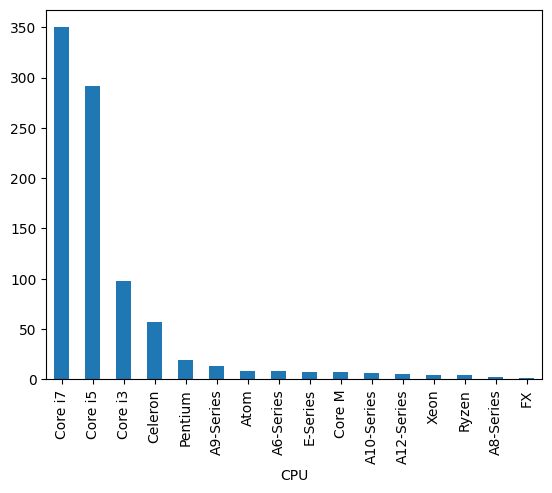

In [45]:
df['CPU'].value_counts().plot(kind='bar')

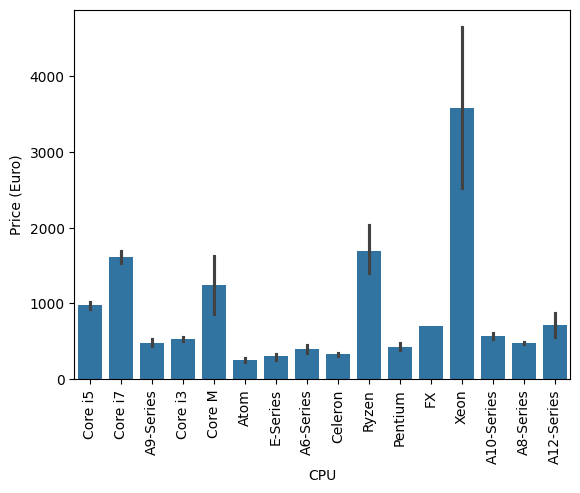

In [46]:
sns.barplot(x=df['CPU'],y=df['Price (Euro)'])
plt.xticks(rotation='vertical')
plt.show()

<Axes: xlabel='RAM (GB)'>

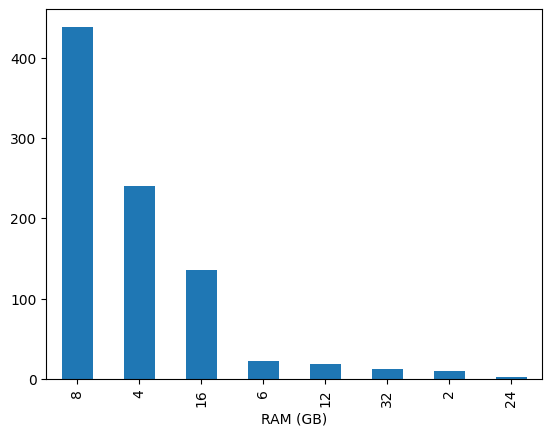

In [47]:
df['RAM (GB)'].value_counts().plot(kind='bar')

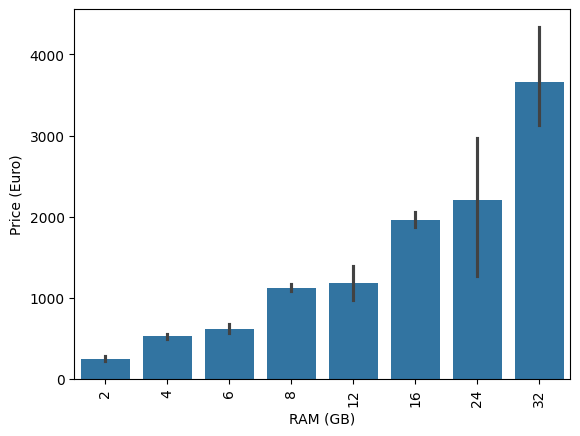

In [48]:
sns.barplot(x=df['RAM (GB)'],y=df['Price (Euro)'])
plt.xticks(rotation='vertical')
plt.show()

In [49]:
df['Memory'].value_counts()

Memory
256GB SSD                        287
1TB HDD                          155
512GB SSD                         83
500GB HDD                         69
128GB SSD +  1TB HDD              63
128GB SSD                         59
256GB SSD +  1TB HDD              48
32GB Flash Storage                25
2TB HDD                           14
256GB SSD +  2TB HDD              10
512GB SSD +  1TB HDD              10
1TB SSD                           10
64GB Flash Storage                 8
32GB SSD                           5
16GB Flash Storage                 5
256GB Flash Storage                4
128GB Flash Storage                4
180GB SSD                          4
16GB SSD                           2
1TB SSD +  1TB HDD                 2
128GB SSD +  2TB HDD               2
1.0TB Hybrid                       1
64GB SSD                           1
256GB SSD +  256GB SSD             1
256GB SSD +  500GB HDD             1
512GB SSD +  256GB SSD             1
512GB SSD +  512GB SSD         

In [50]:
df['Memory'] = df['Memory'].astype(str).replace(r'\.0', '', regex=True)
df["Memory"] = df["Memory"].str.replace('GB', '')
df["Memory"] = df["Memory"].str.replace('TB', '000')
new = df["Memory"].str.split("+", n = 1, expand = True)

df["first"]= new[0]
df["first"]=df["first"].str.strip()

df["second"]= new[1]

df["Layer1HDD"] = df["first"].apply(lambda x: 1 if "HDD" in x else 0)
df["Layer1SSD"] = df["first"].apply(lambda x: 1 if "SSD" in x else 0)
df["Layer1Hybrid"] = df["first"].apply(lambda x: 1 if "Hybrid" in x else 0)
df["Layer1Flash_Storage"] = df["first"].apply(lambda x: 1 if "Flash Storage" in x else 0)

df['first'] = df['first'].str.replace(r'\D', '', regex=True)

df["second"] = df["second"].fillna("0")

df["Layer2HDD"] = df["second"].apply(lambda x: 1 if "HDD" in x else 0)
df["Layer2SSD"] = df["second"].apply(lambda x: 1 if "SSD" in x else 0)
df["Layer2Hybrid"] = df["second"].apply(lambda x: 1 if "Hybrid" in x else 0)
df["Layer2Flash_Storage"] = df["second"].apply(lambda x: 1 if "Flash Storage" in x else 0)

df['second'] = df['second'].str.replace(r'\D', '', regex=True)

df["first"] = df["first"].astype(int)
df["second"] = df["second"].astype(int)

df["HDD"]=(df["first"]*df["Layer1HDD"]+df["second"]*df["Layer2HDD"])
df["SSD"]=(df["first"]*df["Layer1SSD"]+df["second"]*df["Layer2SSD"])
df["Hybrid"]=(df["first"]*df["Layer1Hybrid"]+df["second"]*df["Layer2Hybrid"])
df["Flash_Storage"]=(df["first"]*df["Layer1Flash_Storage"]+df["second"]*df["Layer2Flash_Storage"])

df.drop(columns=['first', 'second', 'Layer1HDD', 'Layer1SSD', 'Layer1Hybrid',
       'Layer1Flash_Storage', 'Layer2HDD', 'Layer2SSD', 'Layer2Hybrid',
       'Layer2Flash_Storage'],inplace=True)

In [51]:
df_test['Memory'] = df_test['Memory'].astype(str).replace(r'\.0', '', regex=True)
df_test["Memory"] = df_test["Memory"].str.replace('GB', '')
df_test["Memory"] = df_test["Memory"].str.replace('TB', '000')
new_test = df_test["Memory"].str.split("+", n = 1, expand = True)

df_test["first"]= new_test[0]
df_test["first"]=df_test["first"].str.strip()

df_test["second"]= new_test[1]

df_test["Layer1HDD"] = df_test["first"].apply(lambda x: 1 if "HDD" in x else 0)
df_test["Layer1SSD"] = df_test["first"].apply(lambda x: 1 if "SSD" in x else 0)
df_test["Layer1Hybrid"] = df_test["first"].apply(lambda x: 1 if "Hybrid" in x else 0)
df_test["Layer1Flash_Storage"] = df_test["first"].apply(lambda x: 1 if "Flash Storage" in x else 0)

df_test['first'] = df_test['first'].str.replace(r'\D', '', regex=True)

df_test["second"] = df_test["second"].fillna("0")

df_test["Layer2HDD"] = df_test["second"].apply(lambda x: 1 if "HDD" in x else 0)
df_test["Layer2SSD"] = df_test["second"].apply(lambda x: 1 if "SSD" in x else 0)
df_test["Layer2Hybrid"] = df_test["second"].apply(lambda x: 1 if "Hybrid" in x else 0)
df_test["Layer2Flash_Storage"] = df_test["second"].apply(lambda x: 1 if "Flash Storage" in x else 0)

df_test['second'] = df_test['second'].str.replace(r'\D', '', regex=True)

df_test["first"] = df_test["first"].astype(int)
df_test["second"] = df_test["second"].astype(int)

df_test["HDD"]=(df_test["first"]*df_test["Layer1HDD"]+df_test["second"]*df_test["Layer2HDD"])
df_test["SSD"]=(df_test["first"]*df_test["Layer1SSD"]+df_test["second"]*df_test["Layer2SSD"])
df_test["Hybrid"]=(df_test["first"]*df_test["Layer1Hybrid"]+df_test["second"]*df_test["Layer2Hybrid"])
df_test["Flash_Storage"]=(df_test["first"]*df_test["Layer1Flash_Storage"]+df_test["second"]*df_test["Layer2Flash_Storage"])

df_test.drop(columns=['first', 'second', 'Layer1HDD', 'Layer1SSD', 'Layer1Hybrid',
       'Layer1Flash_Storage', 'Layer2HDD', 'Layer2SSD', 'Layer2Hybrid',
       'Layer2Flash_Storage'],inplace=True)

In [52]:
df.head()

,Company,TypeName,CPU_Company,CPU_Type,CPU_Frequency (GHz),RAM (GB),Memory,GPU_Company,GPU_Type,OpSys,...,Price (Euro),Touchscreen,Ips,ppi,CPU,CPU_Tier,HDD,SSD,Hybrid,Flash_Storage
0,Apple,Ultrabook,Intel,Core i5,2.3,8,128 SSD,Intel,Iris Plus Graphics 640,macOS,...,1339.69,0,1,226.983005,Core i5,High,0,128,0,0
1,Apple,Ultrabook,Intel,Core i5,1.8,8,128 Flash Storage,Intel,HD Graphics 6000,macOS,...,898.94,0,0,127.677940,Core i5,High,0,0,0,128
2,HP,Notebook,Intel,Core i5 7200U,2.5,8,256 SSD,Intel,HD Graphics 620,No OS,...,575.00,0,0,141.211998,Core i5,High,0,256,0,0
3,Apple,Ultrabook,Intel,Core i7,2.7,16,512 SSD,AMD,Radeon Pro 455,macOS,...,2537.45,0,1,220.534624,Core i7,Very_High,0,512,0,0
4,Apple,Ultrabook,Intel,Core i5,3.1,8,256 SSD,Intel,Iris Plus Graphics 650,macOS,...,1803.60,0,1,226.983005,Core i5,High,0,256,0,0


In [53]:
df.drop(columns=['Memory'],inplace=True)
df_test.drop(columns=['Memory'],inplace=True)

In [54]:
df.corr(numeric_only=True)['Price (Euro)']

CPU_Frequency (GHz)    0.451539
RAM (GB)               0.784077
Weight (kg)            0.241972
Price (Euro)           1.000000
Touchscreen            0.198150
Ips                    0.232332
ppi                    0.490622
HDD                   -0.084962
SSD                    0.677730
Hybrid                -0.010011
Flash_Storage         -0.045146
Name: Price (Euro), dtype: float64

In [55]:
df.drop(columns=['Hybrid','Flash_Storage'],inplace=True)
df_test.drop(columns=['Hybrid','Flash_Storage'],inplace=True)

In [56]:
df['GPU_Type'].value_counts()

GPU_Type
HD Graphics 620       197
HD Graphics 520        83
UHD Graphics 620       66
GeForce GTX 1050       54
Radeon 530             37
                     ... 
Radeon R7 Graphics      1
GeForce 920             1
GeForce 940M            1
GeForce GTX 930MX       1
Radeon R7 M465          1
Name: count, Length: 92, dtype: int64

In [57]:
df['GPU_Company'].value_counts()

GPU_Company
Intel     464
Nvidia    283
AMD       134
Name: count, dtype: int64

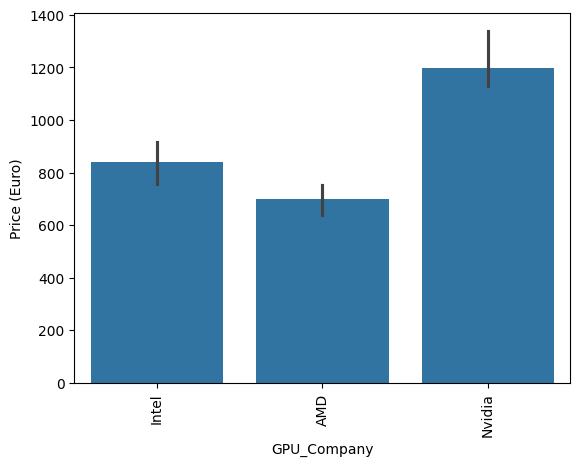

In [58]:
sns.barplot(x=df['GPU_Company'],y=df['Price (Euro)'],estimator=np.median)
plt.xticks(rotation='vertical')
plt.show()

In [59]:
def gpu_tier(gpu_type):
    g = str(gpu_type).lower()
    if 'integrated' in g:
        return 'Integrated'
    if 'mx' in g or '930' in g or '940' in g:
        return 'Entry_dGPU'
    if '950' in g or '960' in g or '1050' in g:
        return 'Mid_dGPU'
    if '1060' in g or '1070' in g or '1080' in g:
        return 'High_dGPU'
    return 'Other_dGPU'
df['GPU_Tier'] = df['GPU_Type'].apply(gpu_tier)
df_test['GPU_Tier'] = df_test['GPU_Type'].apply(gpu_tier)

In [60]:
df.drop(columns=['GPU_Type'],inplace=True)
df_test.drop(columns=['GPU_Type'],inplace=True)

In [61]:
df.drop(columns=['CPU_Type'],inplace=True)
df_test.drop(columns=['CPU_Type'],inplace=True)
df.drop(columns=['CPU_Company'],inplace=True)
df_test.drop(columns=['CPU_Company'],inplace=True)

In [62]:
cpu_tier_map = {'Low': 1, 'Mid': 2, 'High': 3, 'Very_High': 4}
gpu_tier_map = {
    'Integrated': 1,
    'Entry_dGPU': 2,
    'Mid_dGPU': 3,
    'High_dGPU': 4,
    'Other_dGPU': 2
}

In [63]:
df['CPU_Tier']=df['CPU_Tier'].map(cpu_tier_map).fillna(2)
df_test['CPU_Tier']=df_test['CPU_Tier'].map(cpu_tier_map).fillna(2)


In [64]:
df['GPU_Tier']=df['GPU_Tier'].map(gpu_tier_map).fillna(2)
df_test['GPU_Tier']=df_test['GPU_Tier'].map(gpu_tier_map).fillna(2)

In [65]:
df.sample(10)

,Company,TypeName,CPU_Frequency (GHz),RAM (GB),GPU_Company,OpSys,Weight (kg),Price (Euro),Touchscreen,Ips,ppi,CPU,CPU_Tier,HDD,SSD,GPU_Tier
444,HP,Gaming,2.8,8,Nvidia,Windows 10,2.20,1099.0,0,1,141.211998,Core i7,4,1000,128,3
54,Acer,Notebook,2.4,4,Intel,Windows 10,2.40,384.0,0,0,100.454670,Core i3,2,1000,0,2
410,Lenovo,Workstation,2.8,8,Nvidia,Windows 10,2.67,1925.0,0,0,141.211998,Core i7,4,0,512,2
63,Asus,Notebook,1.6,8,Intel,Windows 10,1.40,941.0,0,0,157.350512,Core i5,3,0,256,2
504,Lenovo,Netbook,1.6,4,Intel,Chrome OS,1.25,265.0,0,0,135.094211,Celeron,1,0,16,2
389,Lenovo,2 in 1 Convertible,2.7,16,Intel,Windows 10,1.42,2509.0,1,0,209.800683,Core i7,4,0,512,2
8,Asus,Ultrabook,1.8,16,Nvidia,Windows 10,1.30,1495.0,0,0,157.350512,Core i7,4,0,512,2
641,HP,Notebook,3.0,8,AMD,Windows 10,2.60,520.9,0,0,107.985646,A9-Series,1,1000,0,2
648,Toshiba,Notebook,2.3,8,Intel,Windows 10,1.20,1213.0,0,0,165.632118,Core i5,3,0,256,2
480,Dell,Notebook,1.8,8,Nvidia,Windows 10,2.16,1262.0,0,1,141.211998,Core i7,4,0,512,2


In [66]:
df['TypeName'].value_counts()

TypeName
Notebook              503
Gaming                135
Ultrabook             134
2 in 1 Convertible     72
Workstation            23
Netbook                14
Name: count, dtype: int64

In [67]:
df['OpSys'].value_counts()

OpSys
Windows 10      735
No OS            50
Linux            45
Chrome OS        17
macOS            13
Windows 7         8
Windows 10 S      8
Mac OS X          4
Android           1
Name: count, dtype: int64

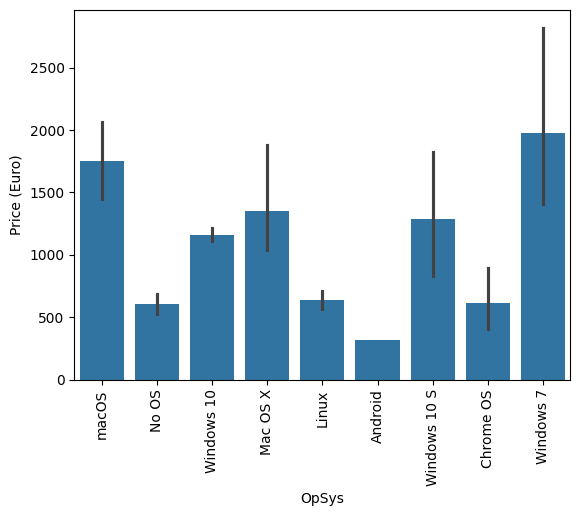

In [68]:
sns.barplot(x=df['OpSys'],y=df['Price (Euro)'])
plt.xticks(rotation='vertical')
plt.show()

In [69]:
def cat_os(inp):
    if inp == 'Windows 10' or inp == 'Windows 7' or inp == 'Windows 10 S':
        return 'Windows'
    elif inp == 'macOS' or inp == 'Mac OS X':
        return 'Mac'
    else:
        return 'Other'

In [70]:
df['OS'] = df['OpSys'].apply(cat_os)
df_test['OS'] = df_test['OpSys'].apply(cat_os)

In [71]:
df.head()

,Company,TypeName,CPU_Frequency (GHz),RAM (GB),GPU_Company,OpSys,Weight (kg),Price (Euro),Touchscreen,Ips,ppi,CPU,CPU_Tier,HDD,SSD,GPU_Tier,OS
0,Apple,Ultrabook,2.3,8,Intel,macOS,1.37,1339.69,0,1,226.983005,Core i5,3,0,128,2,Mac
1,Apple,Ultrabook,1.8,8,Intel,macOS,1.34,898.94,0,0,127.677940,Core i5,3,0,0,2,Mac
2,HP,Notebook,2.5,8,Intel,No OS,1.86,575.00,0,0,141.211998,Core i5,3,0,256,2,Other
3,Apple,Ultrabook,2.7,16,AMD,macOS,1.83,2537.45,0,1,220.534624,Core i7,4,0,512,2,Mac
4,Apple,Ultrabook,3.1,8,Intel,macOS,1.37,1803.60,0,1,226.983005,Core i5,3,0,256,2,Mac


In [72]:
df.drop(columns=['OpSys'],inplace=True)
df_test.drop(columns=['OpSys'],inplace=True)

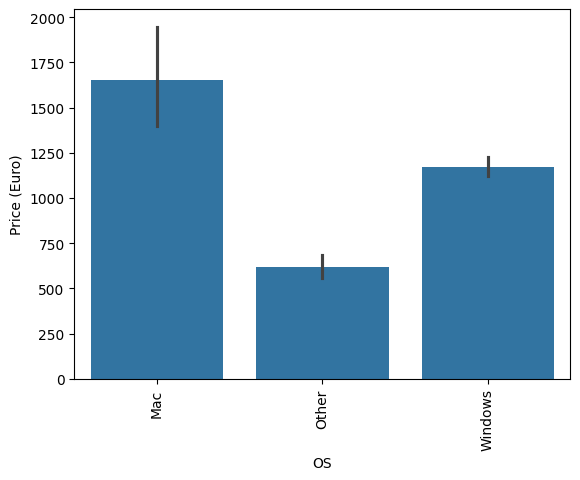

In [73]:
sns.barplot(x=df['OS'],y=df['Price (Euro)'])
plt.xticks(rotation='vertical')
plt.show()

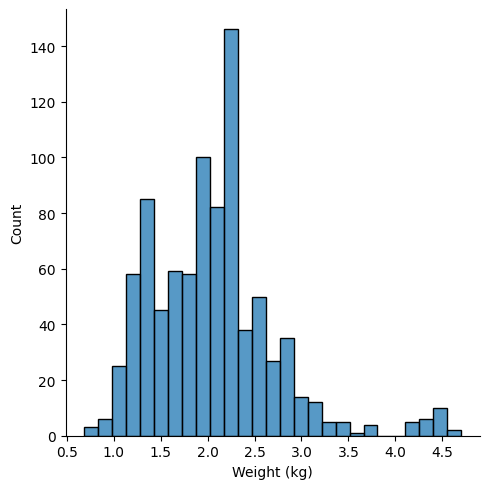

In [74]:
sns.displot(df['Weight (kg)'])

<Axes: xlabel='Weight (kg)', ylabel='Price (Euro)'>

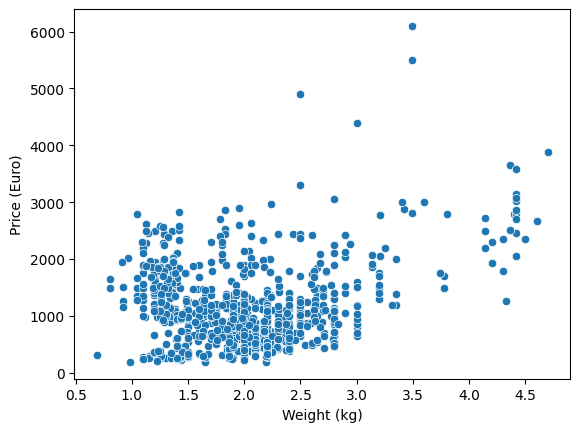

In [75]:
sns.scatterplot(x=df['Weight (kg)'],y=df['Price (Euro)'])

In [76]:
df.corr(numeric_only=True)['Price (Euro)']

CPU_Frequency (GHz)    0.451539
RAM (GB)               0.784077
Weight (kg)            0.241972
Price (Euro)           1.000000
Touchscreen            0.198150
Ips                    0.232332
ppi                    0.490622
CPU_Tier               0.639335
HDD                   -0.084962
SSD                    0.677730
GPU_Tier               0.458633
Name: Price (Euro), dtype: float64

# **EDA**

<Axes: >

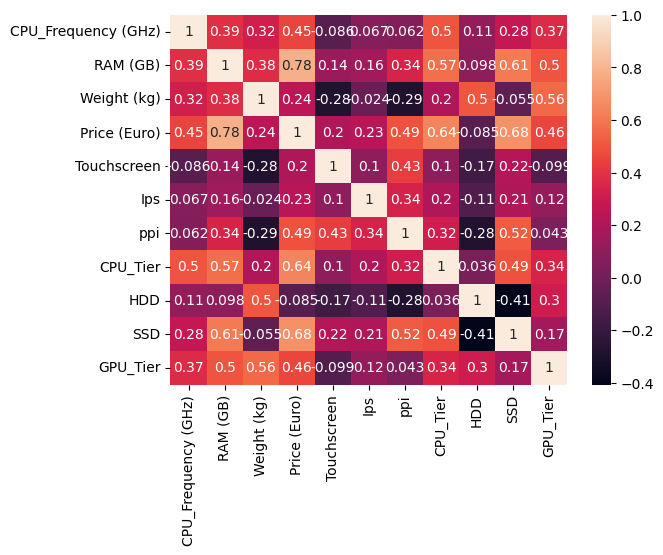

In [77]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

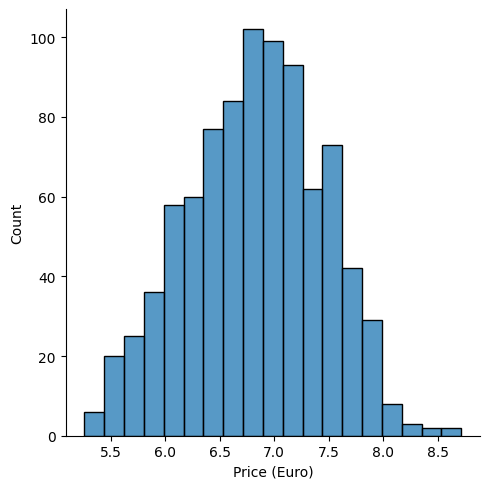

In [78]:
sns.displot(np.log(df['Price (Euro)']))

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              881 non-null    object 
 1   TypeName             881 non-null    object 
 2   CPU_Frequency (GHz)  881 non-null    float64
 3   RAM (GB)             881 non-null    int64  
 4   GPU_Company          881 non-null    object 
 5   Weight (kg)          881 non-null    float64
 6   Price (Euro)         881 non-null    float64
 7   Touchscreen          881 non-null    int64  
 8   Ips                  881 non-null    int64  
 9   ppi                  881 non-null    float64
 10  CPU                  881 non-null    object 
 11  CPU_Tier             881 non-null    int64  
 12  HDD                  881 non-null    int64  
 13  SSD                  881 non-null    int64  
 14  GPU_Tier             881 non-null    int64  
 15  OS                   881 non-null    obj

In [80]:
df['Company'].value_counts()

Company
Lenovo       207
Dell         205
HP           157
Asus         116
Acer          76
Toshiba       31
MSI           30
Apple         17
Mediacom       7
Samsung        7
Microsoft      6
Razer          5
Xiaomi         4
Google         3
Chuwi          3
Huawei         2
Vero           2
Fujitsu        2
LG             1
Name: count, dtype: int64

In [81]:
df.nunique(np.dtype==object)

Company                 19
TypeName                 6
CPU_Frequency (GHz)     25
RAM (GB)                 8
GPU_Company              3
Weight (kg)            157
Price (Euro)           590
Touchscreen              2
Ips                      2
ppi                     35
CPU                     16
CPU_Tier                 4
HDD                      6
SSD                     11
GPU_Tier                 3
OS                       3
dtype: int64

In [82]:
df.head()

,Company,TypeName,CPU_Frequency (GHz),RAM (GB),GPU_Company,Weight (kg),Price (Euro),Touchscreen,Ips,ppi,CPU,CPU_Tier,HDD,SSD,GPU_Tier,OS
0,Apple,Ultrabook,2.3,8,Intel,1.37,1339.69,0,1,226.983005,Core i5,3,0,128,2,Mac
1,Apple,Ultrabook,1.8,8,Intel,1.34,898.94,0,0,127.677940,Core i5,3,0,0,2,Mac
2,HP,Notebook,2.5,8,Intel,1.86,575.00,0,0,141.211998,Core i5,3,0,256,2,Other
3,Apple,Ultrabook,2.7,16,AMD,1.83,2537.45,0,1,220.534624,Core i7,4,0,512,2,Mac
4,Apple,Ultrabook,3.1,8,Intel,1.37,1803.60,0,1,226.983005,Core i5,3,0,256,2,Mac


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              881 non-null    object 
 1   TypeName             881 non-null    object 
 2   CPU_Frequency (GHz)  881 non-null    float64
 3   RAM (GB)             881 non-null    int64  
 4   GPU_Company          881 non-null    object 
 5   Weight (kg)          881 non-null    float64
 6   Price (Euro)         881 non-null    float64
 7   Touchscreen          881 non-null    int64  
 8   Ips                  881 non-null    int64  
 9   ppi                  881 non-null    float64
 10  CPU                  881 non-null    object 
 11  CPU_Tier             881 non-null    int64  
 12  HDD                  881 non-null    int64  
 13  SSD                  881 non-null    int64  
 14  GPU_Tier             881 non-null    int64  
 15  OS                   881 non-null    obj

In [84]:
df_test.head()

,id,Company,TypeName,CPU_Frequency (GHz),RAM (GB),GPU_Company,Weight (kg),Touchscreen,Ips,ppi,CPU,CPU_Tier,HDD,SSD,GPU_Tier,OS
0,882,HP,2 in 1 Convertible,2.5,4,Intel,2.30,1,0,100.454670,Core i5,3,500,0,2,Windows
1,883,Asus,Notebook,1.1,4,Intel,1.65,0,0,111.141337,Celeron,1,0,0,2,Windows
2,884,Lenovo,Notebook,2.5,8,Nvidia,2.20,0,1,141.211998,Core i7,4,1000,0,2,Windows
3,885,Dell,Notebook,1.6,4,Intel,2.20,0,0,100.454670,Pentium,1,500,0,2,Windows
4,886,HP,2 in 1 Convertible,2.5,4,Intel,1.28,1,0,165.632118,Core i5,3,0,256,2,Windows


In [85]:
df_test.shape

(394, 16)

In [86]:
df.head()

,Company,TypeName,CPU_Frequency (GHz),RAM (GB),GPU_Company,Weight (kg),Price (Euro),Touchscreen,Ips,ppi,CPU,CPU_Tier,HDD,SSD,GPU_Tier,OS
0,Apple,Ultrabook,2.3,8,Intel,1.37,1339.69,0,1,226.983005,Core i5,3,0,128,2,Mac
1,Apple,Ultrabook,1.8,8,Intel,1.34,898.94,0,0,127.677940,Core i5,3,0,0,2,Mac
2,HP,Notebook,2.5,8,Intel,1.86,575.00,0,0,141.211998,Core i5,3,0,256,2,Other
3,Apple,Ultrabook,2.7,16,AMD,1.83,2537.45,0,1,220.534624,Core i7,4,0,512,2,Mac
4,Apple,Ultrabook,3.1,8,Intel,1.37,1803.60,0,1,226.983005,Core i5,3,0,256,2,Mac


# **Prepping Test Data**

In [87]:
X=df.drop(columns=['Price (Euro)'])
y=np.log(df['Price (Euro)'])

In [88]:
df_test.head()

,id,Company,TypeName,CPU_Frequency (GHz),RAM (GB),GPU_Company,Weight (kg),Touchscreen,Ips,ppi,CPU,CPU_Tier,HDD,SSD,GPU_Tier,OS
0,882,HP,2 in 1 Convertible,2.5,4,Intel,2.30,1,0,100.454670,Core i5,3,500,0,2,Windows
1,883,Asus,Notebook,1.1,4,Intel,1.65,0,0,111.141337,Celeron,1,0,0,2,Windows
2,884,Lenovo,Notebook,2.5,8,Nvidia,2.20,0,1,141.211998,Core i7,4,1000,0,2,Windows
3,885,Dell,Notebook,1.6,4,Intel,2.20,0,0,100.454670,Pentium,1,500,0,2,Windows
4,886,HP,2 in 1 Convertible,2.5,4,Intel,1.28,1,0,165.632118,Core i5,3,0,256,2,Windows


In [89]:
df.head()

,Company,TypeName,CPU_Frequency (GHz),RAM (GB),GPU_Company,Weight (kg),Price (Euro),Touchscreen,Ips,ppi,CPU,CPU_Tier,HDD,SSD,GPU_Tier,OS
0,Apple,Ultrabook,2.3,8,Intel,1.37,1339.69,0,1,226.983005,Core i5,3,0,128,2,Mac
1,Apple,Ultrabook,1.8,8,Intel,1.34,898.94,0,0,127.677940,Core i5,3,0,0,2,Mac
2,HP,Notebook,2.5,8,Intel,1.86,575.00,0,0,141.211998,Core i5,3,0,256,2,Other
3,Apple,Ultrabook,2.7,16,AMD,1.83,2537.45,0,1,220.534624,Core i7,4,0,512,2,Mac
4,Apple,Ultrabook,3.1,8,Intel,1.37,1803.60,0,1,226.983005,Core i5,3,0,256,2,Mac


In [90]:
df_test.head()

,id,Company,TypeName,CPU_Frequency (GHz),RAM (GB),GPU_Company,Weight (kg),Touchscreen,Ips,ppi,CPU,CPU_Tier,HDD,SSD,GPU_Tier,OS
0,882,HP,2 in 1 Convertible,2.5,4,Intel,2.30,1,0,100.454670,Core i5,3,500,0,2,Windows
1,883,Asus,Notebook,1.1,4,Intel,1.65,0,0,111.141337,Celeron,1,0,0,2,Windows
2,884,Lenovo,Notebook,2.5,8,Nvidia,2.20,0,1,141.211998,Core i7,4,1000,0,2,Windows
3,885,Dell,Notebook,1.6,4,Intel,2.20,0,0,100.454670,Pentium,1,500,0,2,Windows
4,886,HP,2 in 1 Convertible,2.5,4,Intel,1.28,1,0,165.632118,Core i5,3,0,256,2,Windows


In [91]:
X_test=df_test[X.columns]

In [92]:
X_test.head()

,Company,TypeName,CPU_Frequency (GHz),RAM (GB),GPU_Company,Weight (kg),Touchscreen,Ips,ppi,CPU,CPU_Tier,HDD,SSD,GPU_Tier,OS
0,HP,2 in 1 Convertible,2.5,4,Intel,2.30,1,0,100.454670,Core i5,3,500,0,2,Windows
1,Asus,Notebook,1.1,4,Intel,1.65,0,0,111.141337,Celeron,1,0,0,2,Windows
2,Lenovo,Notebook,2.5,8,Nvidia,2.20,0,1,141.211998,Core i7,4,1000,0,2,Windows
3,Dell,Notebook,1.6,4,Intel,2.20,0,0,100.454670,Pentium,1,500,0,2,Windows
4,HP,2 in 1 Convertible,2.5,4,Intel,1.28,1,0,165.632118,Core i5,3,0,256,2,Windows


In [93]:
target_col = 'Price (Euro)'
categorical_features = ['Company','TypeName','GPU_Company','CPU','OS']
numeric_features = [c for c in df.columns
                    if c not in categorical_features + [target_col, 'id']]

# **Model Implementation**

### **Linear Regression**

In [94]:
preprocess = ColumnTransformer(transformers=[
                    ("num_poly", Pipeline([
                ("scale", StandardScaler()),
            ]), numeric_features),
            ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_features),])

model = Pipeline([
        ("pre", preprocess),
        ("reg", LinearRegression())
    ])

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

r2 = cross_val_score(model, X, y, cv=kfold, scoring="r2")

mse = -cross_val_score(model, X, y, cv=kfold, scoring="neg_mean_squared_error")

mae = -cross_val_score(model, X, y, cv=kfold, scoring="neg_mean_absolute_error")

In [95]:
print("R2 per fold:", r2)
print("Mean R2:", r2.mean())
print("MSE per fold:", mse)
print("Mean MSE:", mse.mean())
print("MAE per fold:", mae)
print("Mean MAE:", mae.mean())

R2 per fold: [0.88444473 0.87298134 0.86930189 0.87364706 0.86388204]
Mean R2: 0.8728514125274419
MSE per fold: [0.05029073 0.04285473 0.04767416 0.05119876 0.0512    ]
Mean MSE: 0.048643675226904035
MAE per fold: [0.17983184 0.16332591 0.17373883 0.18232186 0.17808935]
Mean MAE: 0.17546155693605475


### **Polynomial Regression**

In [96]:
degrees = [2,3,4,5]
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
best_degree = None
best_score = -np.inf
best_poly_model = None

for d in degrees:
    preprocess = ColumnTransformer(
    transformers=[
        ("num_poly", Pipeline([
        ("scale", StandardScaler()),
        ("poly", PolynomialFeatures(degree=d, include_bias=False, interaction_only=True)),]), numeric_features),
        ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_features),])

    model = Pipeline([
    ("pre", preprocess),
    ("reg", LinearRegression())
    ])
    
    scores = cross_val_score(model, X, y, cv=kfold, scoring="r2")
    mean_score = scores.mean()
    print(f"Degree {d}")
    print("R2 per fold:", scores)
    print("Mean R2:", scores.mean())
    print("======================")
    if mean_score > best_score:
        best_score = mean_score        
        best_degree = d
        best_poly_model = model

print("Best degree:", best_degree)
print("Best CV R2:", best_score)

best_poly_model.fit(X, y)



Degree 2
R2 per fold: [0.88434234 0.87527643 0.87329807 0.88284049 0.86643595]
Mean R2: 0.8764386552721041
Degree 3
R2 per fold: [ 0.27048014  0.69331102 -2.05036751 -0.25408235  0.7899126 ]
Mean R2: -0.11014921905897238
Degree 4
R2 per fold: [  -622.52846904   -956.68383641   -290.47384987 -30130.82207801
    -60.09462341]
Mean R2: -6412.120571347942
Degree 5
R2 per fold: [-1415.90522231 -1083.71772661 -1425.79353503 -3742.99469325
  -259.28622452]
Mean R2: -1585.5394803443344
Best degree: 2
Best CV R2: 0.8764386552721041


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_poly', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains

### **Ridge Regression**

In [97]:
preprocess = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

ridge_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("ridge", Ridge())
])

param_grid = {"ridge__alpha": np.logspace(-3, 3, 7)}
kfold = KFold(n_splits=5, random_state=42, shuffle=True)

ridge_search = GridSearchCV(
    ridge_pipeline, param_grid,
    cv=kfold,
    return_train_score=True,
    verbose=2,              
    n_jobs=-1)               

ridge_search.fit(X, y)

best_alpha = ridge_search.best_params_["ridge__alpha"]
print(f"Best Alpha: {best_alpha}")

best_ridge = ridge_search.best_estimator_

r2 = cross_val_score(best_ridge, X, y, cv=kfold, scoring="r2")
mae = cross_val_score(best_ridge, X, y, cv=kfold, scoring="neg_mean_absolute_error")
mse = cross_val_score(best_ridge, X, y, cv=kfold, scoring="neg_mean_squared_error")

print("R2 per fold:", r2)
print("Mean R2:", r2.mean())
print("MSE per fold:", mse)
print("Mean MSE:", mse.mean())
print("MAE per fold:", mae)
print("Mean MAE:", mae.mean())

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best Alpha: 0.1
R2 per fold: [0.88453049 0.87337015 0.86989617 0.87393145 0.86313595]
Mean R2: 0.8729728400510121
MSE per fold: [-0.0502534  -0.04272355 -0.04745739 -0.05108352 -0.05148064]
Mean MSE: -0.04859970111805357
MAE per fold: [-0.18007942 -0.16302355 -0.17305642 -0.18163987 -0.17887561]
Mean MAE: -0.17533497594590974


### **Lasso Regression**

In [98]:
lasso_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("lasso", Lasso(max_iter=10000))
])


param_grid = {"lasso__alpha": np.logspace(-5, 2, 20)} 

lasso_search = GridSearchCV(
    lasso_pipeline, param_grid,
    cv=kfold,
    return_train_score=True,
    verbose=2,             
    n_jobs=-1)             

lasso_search.fit(X, y)

best_alpha = lasso_search.best_params_["lasso__alpha"]
print(f"Best Alpha: {best_alpha}")

best_lasso = lasso_search.best_estimator_


r2 = cross_val_score(best_lasso, X, y, cv=kfold, scoring="r2")
mae = cross_val_score(best_lasso, X, y, cv=kfold, scoring="neg_mean_absolute_error")
mse = cross_val_score(best_lasso, X, y, cv=kfold, scoring="neg_mean_squared_error")

print("R2 per fold:", r2)
print("Mean R2:", r2.mean())
print("MSE per fold:", mse)
print("Mean MSE:", mse.mean())
print("MAE per fold:", mae)
print("Mean MAE:", mae.mean())


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Alpha: 2.3357214690901213e-05
R2 per fold: [0.88404135 0.87292504 0.86938621 0.87366393 0.86396985]
Mean R2: 0.8727972754057814
MSE per fold: [-0.05046628 -0.04287373 -0.0476434  -0.05119192 -0.05116697]
Mean MSE: -0.04866846111551971
MAE per fold: [-0.18016179 -0.16340873 -0.1736217  -0.18221578 -0.17790686]
Mean MAE: -0.17546297318256035


### **Elastic Net Regression (EXTRA)** 

In [99]:

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)
net = Pipeline(steps=[
    ("preprocess", preprocess),
    ("elastic", ElasticNet(alpha=0.001,max_iter=10000))
])
kfold = KFold(n_splits=5, shuffle=True, random_state=42)


r2= cross_val_score(net, X, y, cv=kfold, scoring="r2")
mse = -cross_val_score(net, X, y, cv=kfold, scoring="neg_mean_squared_error")
mae = -cross_val_score(net, X, y, cv=kfold, scoring="neg_mean_absolute_error")

print("R2 per fold:", r2)
print("Mean R2:", r2.mean())

print("MSE per fold:", mse)
print("Mean MSE:", mse.mean())

print("MAE per fold:", mae)
print("Mean MAE:", mae.mean())

R2 per fold: [0.87823466 0.87252014 0.86817046 0.86895951 0.84931754]
Mean R2: 0.8674404639763766
MSE per fold: [0.05299341 0.04301033 0.04808687 0.05309817 0.05667836]
Mean MSE: 0.050773426782707895
MAE per fold: [0.18622893 0.16298277 0.17174399 0.18686336 0.18621455]
Mean MAE: 0.1788067196596431


### **Regression Trees**

In [100]:
depths = [2,3,4,5,6]

for d in depths:

    preprocess = ColumnTransformer(
        transformers=[
            ("num", "passthrough", numeric_features),
            ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ]
    )

    model = Pipeline([
        ("pre", preprocess),
        ("reg", DecisionTreeRegressor(max_depth=d, random_state=42))
    ])

    kfold = KFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(model, X, y, cv=kfold, scoring="r2")

    print(f"Tree Depth {d}")
    print("R2 per fold:", scores)
    print("Mean R2:", scores.mean())
    print("======================")

Tree Depth 2
R2 per fold: [0.66325137 0.64001107 0.6278045  0.63307208 0.60575576]
Mean R2: 0.6339789546408348
Tree Depth 3
R2 per fold: [0.72696795 0.72383136 0.7344062  0.74457633 0.73363876]
Mean R2: 0.7326841216281472
Tree Depth 4
R2 per fold: [0.76205433 0.75194953 0.78732604 0.77214262 0.7664704 ]
Mean R2: 0.7679885866530911
Tree Depth 5
R2 per fold: [0.80221288 0.75401782 0.80938537 0.78445531 0.78318709]
Mean R2: 0.7866516944212177
Tree Depth 6
R2 per fold: [0.80481043 0.75671278 0.82288565 0.8038591  0.76073125]
Mean R2: 0.7897998426325077


### **Learnig Curve**

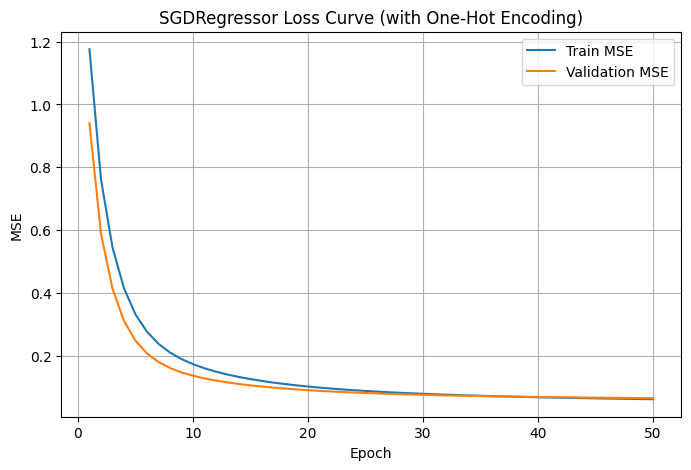

In [101]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

target_col = 'Price (Euro)'

categorical_features = ['Company','TypeName','GPU_Company','CPU','OS']
numeric_features = [c for c in df.columns
                    if c not in categorical_features + [target_col, 'id']]

X = df.drop(columns=[target_col])
y = np.log(df[target_col])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

epochs = 50

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

model = Pipeline([
    ("preprocess", preprocess),
    ("sgd", SGDRegressor(
        loss="squared_error",
        penalty="l2",
        alpha=1e-4,
        learning_rate="invscaling",
        eta0=0.01,
        power_t=0.25,
        max_iter=1,       
        tol=None,
        random_state=42,
        warm_start=True,
        fit_intercept=True,
        average=False
    ))
])

train_mse, val_mse = [], []

for epoch in range(1, epochs + 1):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    train_mse.append(mean_squared_error(y_train, train_pred))
    val_mse.append(mean_squared_error(y_val, val_pred))

plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), train_mse, label="Train MSE")
plt.plot(range(1, epochs+1), val_mse, label="Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("SGDRegressor Loss Curve (with One-Hot Encoding)")
plt.grid(True)
plt.legend()
plt.show()

### **Saving Preditions to Test Dataset and Creating a Submission File**

In [102]:
y_test_pred = best_ridge.predict(X_test)

y_test_pred = np.exp(y_test_pred)

df_test['Price (Euro)'] = y_test_pred

submission = df_test[['id', 'Price (Euro)']]

submission.to_csv('submission.csv', index=False)